In [ ]:
%load_ext autoreload
%autoreload 2

import sys; sys.path += ['./../']
import numpy as np
from CardamomOT import train_classifier, predict_cell_types, plot_cell_type_proportions
import anndata as ad
import getopt
import scipy
import scanpy as sc
import matplotlib.pyplot as plt

label="cell_type"

def check_cell_types_full(clf, p, stim=1.0, prior=1.0):

    ### Compare cell type on mRNA
    adata_train = ad.read_h5ad(p+'cardamomOT/adata_rna_traj_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_beta = ad.read_h5ad(p+'cardamomOT/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train = ad.read_h5ad(p+'cardamomOT/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train = ad.read_h5ad(p+'cardamomOT/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))

    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_beta = predict_cell_types(adata_beta, clf, label_key=label)
    adata_sim_train = predict_cell_types(adata_sim_train, clf, label_key=label)
    adata_theta_train = predict_cell_types(adata_theta_train, clf, label_key=label)

    adata_train.write(p+'cardamomOT/adata_rna_traj_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_beta.write(p+'cardamomOT/adata_beta_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_sim_train.write(p+'cardamomOT/adata_sim_stim{}_prior{}.h5ad'.format(stim, prior))
    adata_theta_train.write(p+'cardamomOT/adata_theta_stim{}_prior{}.h5ad'.format(stim, prior))

    cmap_cat = plt.get_cmap('Dark2')
    cats = adata_train.obs["cell_type"].astype(str).unique().tolist()
    colors = [cmap_cat(i % 20) for i in range(len(cats))]
    
    plot_cell_type_proportions(
    adatas=[adata_train, adata_beta, adata_theta_train, adata_sim_train],
    labels=["data", "NB mixture", "modes", "sim"],
    label_key=label, colors=colors
    )

def check_cell_types_mixture(clf, p, adata_full, stim=1.0, prior=1.0):

    ### Compare cell type on mRNA
    adata_train = ad.read_h5ad(p+'cardamomOT/adata_beta.h5ad')
    adata_train = predict_cell_types(adata_train, clf, label_key=label)
    adata_train.write(p+'cardamomOT/adata_beta.h5ad'.format(stim, prior))

    plot_cell_type_proportions(
    adatas=[adata_full, adata_train],
    labels=["train", "mixture train"],
    label_key=label
    )

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


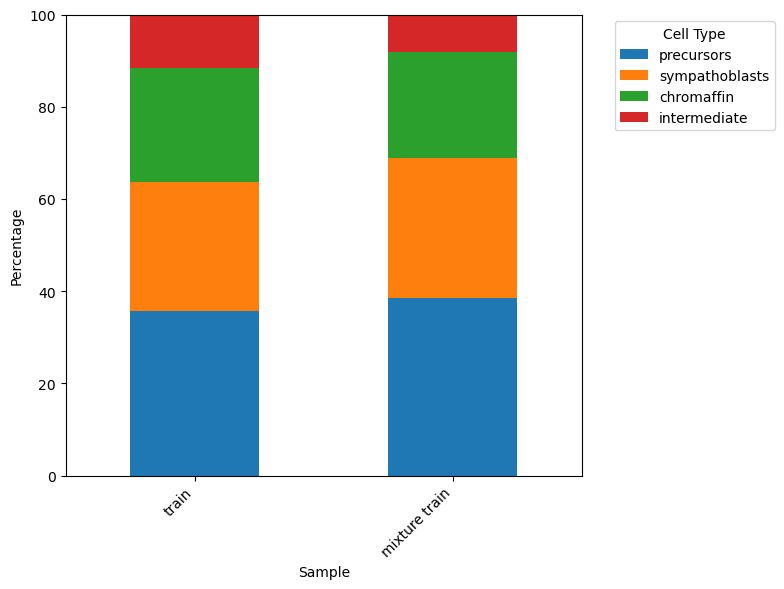

cell_type      precursors  sympathoblasts  chromaffin  intermediate
train           35.722222       28.055556   24.722222     11.500000
mixture train   38.444444       30.388889   23.111111      8.055556


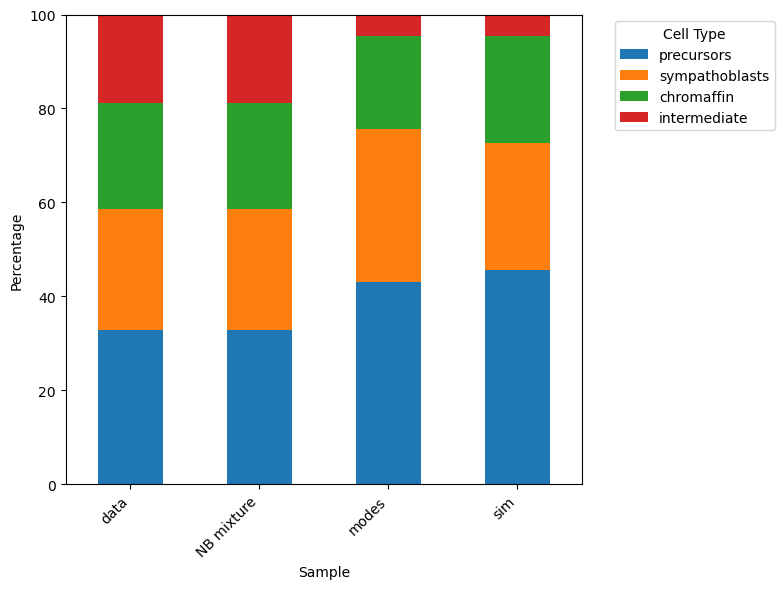

cell_type   precursors  sympathoblasts  chromaffin  intermediate
data         32.888889       25.666667   22.611111     18.833333
NB mixture   32.888889       25.666667   22.611111     18.833333
modes        43.000000       32.555556   19.944444      4.500000
sim          45.555556       27.166667   22.611111      4.666667


In [32]:
p = './../experimental_datasets/Kameneva/' 

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, adata_full)
check_cell_types_full(clf, p)

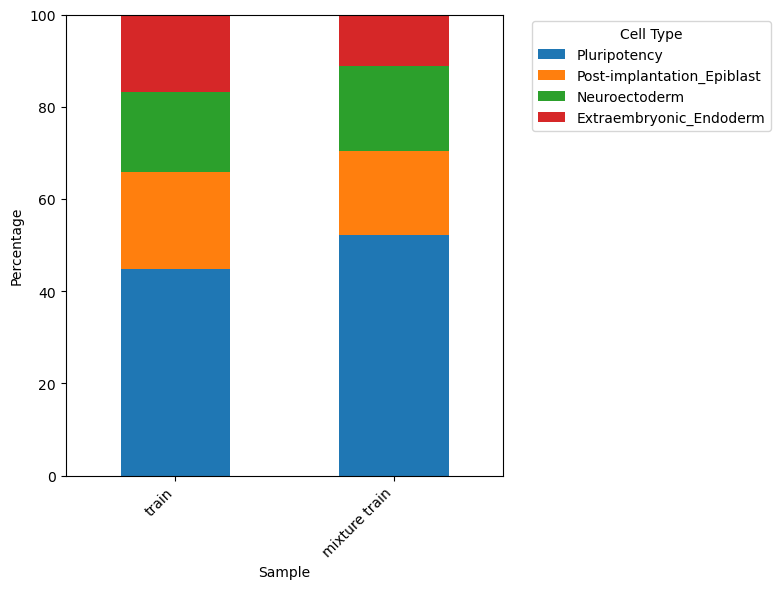

cell_type      Pluripotency  Post-implantation_Epiblast  Neuroectoderm  \
train             44.712127                   21.069824      17.517354   
mixture train     52.225398                   18.129849      18.579012   

cell_type      Extraembryonic_Endoderm  
train                        16.700694  
mixture train                11.065741  


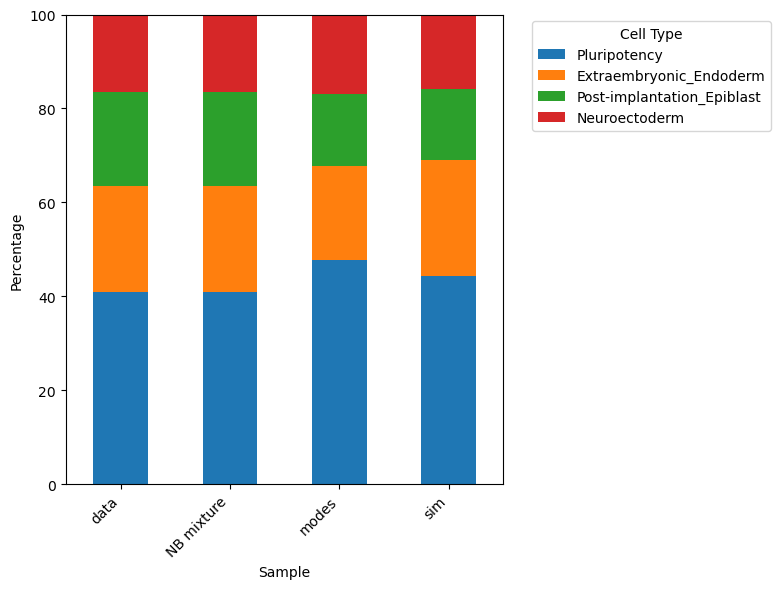

cell_type   Pluripotency  Extraembryonic_Endoderm  Post-implantation_Epiblast  \
data           40.981241                22.619048                   19.877345   
NB mixture     40.981241                22.619048                   19.877345   
modes          47.763348                20.057720                   15.295815   
sim            44.336219                24.639250                   15.079365   

cell_type   Neuroectoderm  
data            16.522367  
NB mixture      16.522367  
modes           16.883117  
sim             15.945166  


In [33]:
p = './../experimental_datasets/Semrau/'

adata_full = ad.read_h5ad(p+'Data/data_full.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, adata_full)
check_cell_types_full(clf, p)

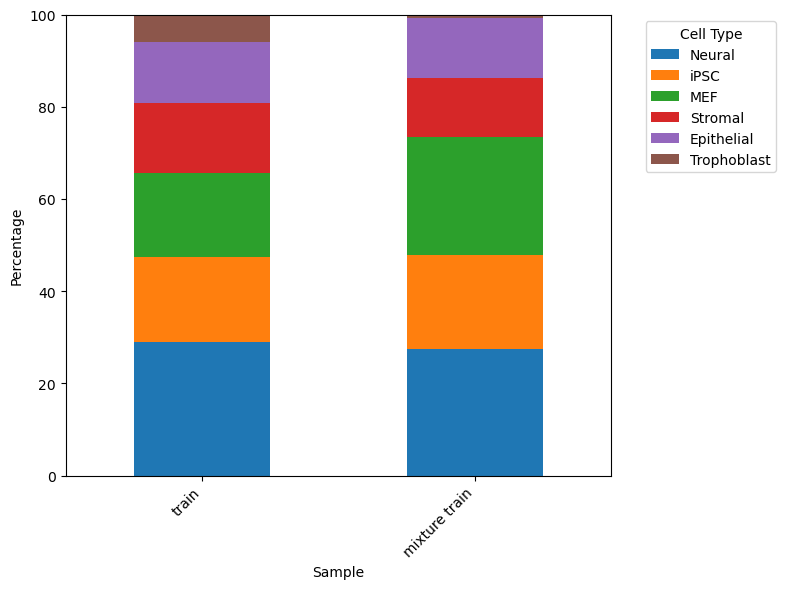

cell_type         Neural       iPSC       MEF    Stromal  Epithelial  \
train          29.055016  18.317965  18.29940  15.099944   13.243394   
mixture train  27.486359  20.343502  25.62624  12.766617   13.039435   

cell_type      Trophoblast  
train             5.984281  
mixture train     0.737847  


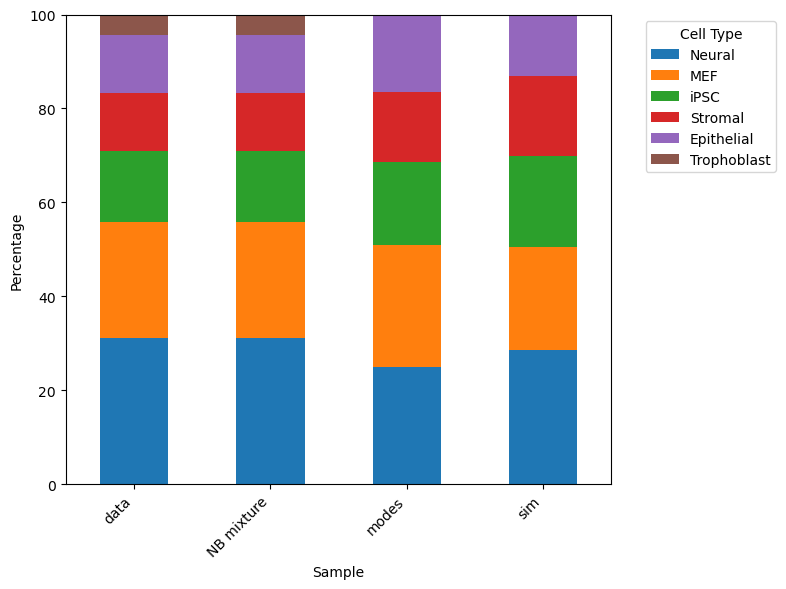

cell_type      Neural        MEF       iPSC    Stromal  Epithelial  \
data        31.168547  24.717922  15.052917  12.455174   12.337094   
NB mixture  31.168547  24.717922  15.052917  12.455174   12.337094   
modes       25.045920  25.924954  17.659407  14.934838   16.093764   
sim         28.614537  21.814047  19.395609  17.016531   12.975597   

cell_type   Trophoblast  
data           4.268346  
NB mixture     4.268346  
modes          0.341118  
sim            0.183679  


In [34]:
p = './../experimental_datasets/Schiebinger/'

adata_full = ad.read_h5ad(p+'Data/data_train.h5ad')
clf = train_classifier(adata_full, label_key=label)
check_cell_types_mixture(clf, p, adata_full)
check_cell_types_full(clf, p)